<a href="https://colab.research.google.com/github/vinodarali/Eye-disease-detection/blob/main/covid_VGG16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import the necessary packages
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from imutils import paths
import matplotlib.pyplot as plt
import numpy as np
import argparse
import cv2
import os
from keras.applications.resnet50 import ResNet50
from keras.preprocessing import image
from keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np


In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Conv2D, MaxPool2D, Flatten
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
!git clone https://github.com/vaibhavG321/Classification-of-COVID-19-chest-X-ray-images

Cloning into 'Classification-of-COVID-19-chest-X-ray-images'...
remote: Enumerating objects: 901, done.
remote: Counting objects: 100% (245/245), done.
remote: Compressing objects: 100% (166/166), done.
remote: Total 901 (delta 58), reused 224 (delta 48), pack-reused 656 (from 1)
Receiving objects: 100% (901/901), 235.19 MiB | 16.42 MiB/s, done.
Resolving deltas: 100% (86/86), done.
Updating files: 100% (807/807), done.


In [4]:
!ls

Classification-of-COVID-19-chest-X-ray-images  sample_data


In [5]:
cd Classification-of-COVID-19-chest-X-ray-images

/content/Classification-of-COVID-19-chest-X-ray-images


In [6]:
!ls

 aditi-godbole-model.py		    covid19_project_pruning.ipynb
 aditi-verma-model.py		    covid_VGG16.ipynb
 aditya-babar-model.py		    dataset
 aditya-gurnani-model.py	   'ionic application'
 augmentation.ipynb		    README.md
 covid19_internship_project.ipynb   test1.ipynb
 covid19_project.ipynb		    vaibhav-model.py


In [7]:
cd dataset

/content/Classification-of-COVID-19-chest-X-ray-images/dataset


In [8]:
!ls

evaluation  testing  training


In [9]:
cd training

/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training


In [10]:
!ls

infected  normal


In [11]:
train_normal_path='/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/normal'
train_infected_path='/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected'
test_normal_path='/content/Classification-of-COVID-19-chest-X-ray-images/dataset/testing/normal'
test_infected_path='/content/Classification-of-COVID-19-chest-X-ray-images/dataset/testing/infected'
evaluate_normal_path='/content/Classification-of-COVID-19-chest-X-ray-images/dataset/evaluation/normal'
evaluate_infected_path='/content/Classification-of-COVID-19-chest-X-ray-images/dataset/evaluation/infected'

In [12]:
print('train_normal cases ',len(os.listdir('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/normal')))
print('train_infected cases ',len(os.listdir('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected')))
print('test_normal cases ',len(os.listdir('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/testing/normal')))
print('test_infected cases ',len(os.listdir('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/testing/infected')))
print('evaluate_normal cases ',len(os.listdir('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/evaluation/normal')))
print('evaluate_infected cases ',len(os.listdir('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/evaluation/infected')))

train_normal cases  297
train_infected cases  296
test_normal cases  69
test_infected cases  25
evaluate_normal cases  1
evaluate_infected cases  1


In [13]:
IMAGE_SIZE = (224,224)
DIR_NAME = '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/'
IMAGE_DIR = DIR_NAME + 'normal/'
imagePaths=[]
for dirname, _, filenames in os.walk(DIR_NAME):
    for filename in filenames:
      imagePaths.append(os.path.join(dirname, filename))

In [14]:
imagePaths

['/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (15).jpg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (57).jpg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (11).jpeg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (14).jpg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (106).jpg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (43).jpeg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (25).jpg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (32).jpg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train24.jpeg',
 '/content/Classification-of-COVID-19-chest-X

In [15]:
data = []
labels = []
# loop over the image paths
for imagePath in imagePaths:
	# extract the class label from the filename
	label = imagePath.split(os.path.sep)[-2]
	# load the image, swap color channels, and resize it to be a fixed
	# 224x224 pixels while ignoring aspect ratio
	image = cv2.imread(imagePath)
	image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
	image = cv2.resize(image, (224, 224))
	# update the data and labels lists, respectively
	data.append(image)
	labels.append(label)
# convert the data and labels to NumPy arrays while scaling the pixel
# intensities to the range [0, 1]
data = np.array(data) / 255.0
labels = np.array(labels)

In [16]:
data.shape

(689, 224, 224, 3)

In [17]:
labels


array(['infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infect

In [18]:
# perform one-hot encoding on the labels
lb = LabelBinarizer()
labels = lb.fit_transform(labels)
labels = to_categorical(labels)
# partition the data into training and testing splits using 80% of
# the data for training and the remaining 20% for testing
(trainX, testX, trainY, testY) = train_test_split(data, labels,
	test_size=0.20, stratify=labels, random_state=42)
# initialize the training data augmentation object
trainAug = ImageDataGenerator(shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,	rotation_range=15,
	fill_mode="nearest")

In [19]:
trainAug

In [20]:
trainX.shape,testX.shape,trainY.shape,testY.shape

((551, 224, 224, 3), (138, 224, 224, 3), (551, 2), (138, 2))

USING VGG16 MODEL

In [21]:
baseModel = VGG16(weights="imagenet", include_top=False,
	input_tensor=Input(shape=(224, 224, 3)))
# construct the head of the model that will be placed on top of the
# the base model
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)
# place the head FC model on top of the base model (this will become
# the actual model we will train)
model = Model(inputs=baseModel.input, outputs=headModel)
# loop over all layers in the base model and freeze them so they will
# *not* be updated during the first training process
for layer in baseModel.layers:
	layer.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [22]:
model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)


In [23]:
# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 0.001
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.6112 - loss: 0.7160

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 28s 298ms/step - accuracy: 0.6796 - loss: 0.6365 - val_accuracy: 0.8406 - val_loss: 0.5045
Epoch 2/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.8750 - loss: 0.5122

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8750 - loss: 0.5122 - val_accuracy: 0.8406 - val_loss: 0.5039
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - accuracy: 0.8306 - loss: 0.4752 - val_accuracy: 0.9130 - val_loss: 0.3663
Epoch 4/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8750 - loss: 0.3687 - val_accuracy: 0.9130 - val_loss: 0.3660
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 139ms/step - accuracy: 0.8619 - loss: 0.3925 - val_accuracy: 0.9420 - val_loss: 0.2833
Epoch 6/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 1.0000 - loss: 0.2148

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 0.2148 - val_accuracy: 0.9420 - val_loss: 0.2806
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.9024 - loss: 0.3096 - val_accuracy: 0.9420 - val_loss: 0.2135
Epoch 8/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8750 - loss: 0.3675 - val_accuracy: 0.9420 - val_loss: 0.2150
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.8950 - loss: 0.2768 - val_accuracy: 0.9493 - val_loss: 0.1702
Epoch 10/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 0.0877 - val_accuracy: 0.9493 - val_loss: 0.1699
Epoch 11/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - accuracy: 0.9263 - loss: 0.2354 - val_accuracy: 0.9493 - val_loss: 0.1445
Epoch 12/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 0.2187 - val_accuracy: 0.9493 - val_loss: 0.1442
Epoch 13/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - accuracy: 0.9282 - loss: 0.2112 - val_accuracy: 0.9638 - val_

In [24]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 208ms/step
              precision    recall  f1-score   support

    infected       1.00      0.94      0.97        64
      normal       0.95      1.00      0.97        74

    accuracy                           0.97       138
   macro avg       0.97      0.97      0.97       138
weighted avg       0.97      0.97      0.97       138



In [25]:
# compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))


[[60  4]
 [ 0 74]]
acc: 0.9710
sensitivity: 0.9375
specificity: 1.0000


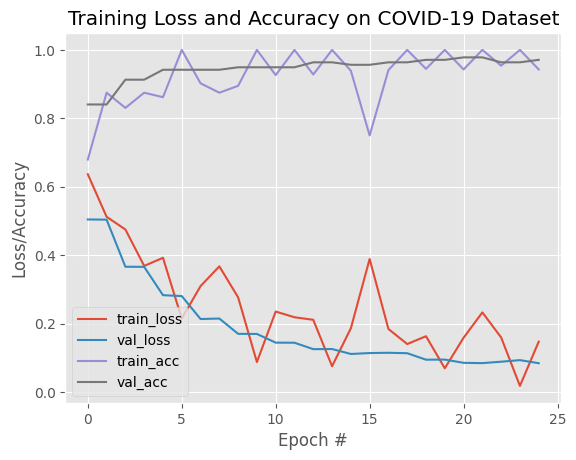

In [26]:
# plot the training loss and accuracy
N = EPOCHS
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

In [27]:
predIdxs

array([0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


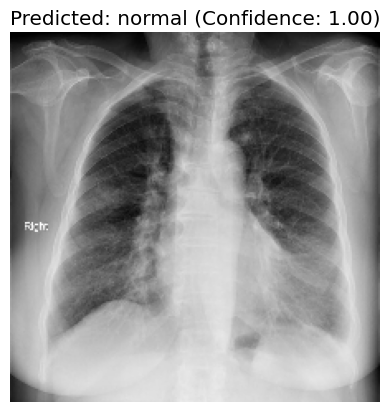

In [28]:
#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image_path = '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (1).jpeg'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
resized_image = cv2.resize(image, (224, 224))
img=np.reshape(resized_image,(1,224,224,3))

# Make prediction
prediction = model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

Displaying predictions for 4 images:
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


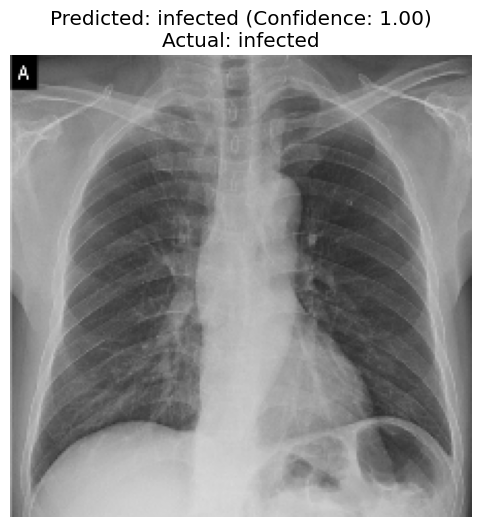

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


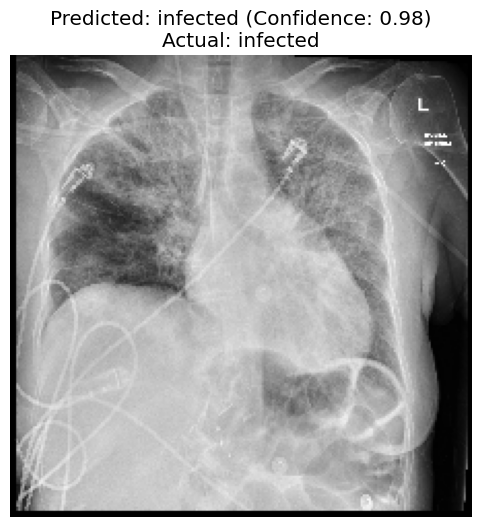

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


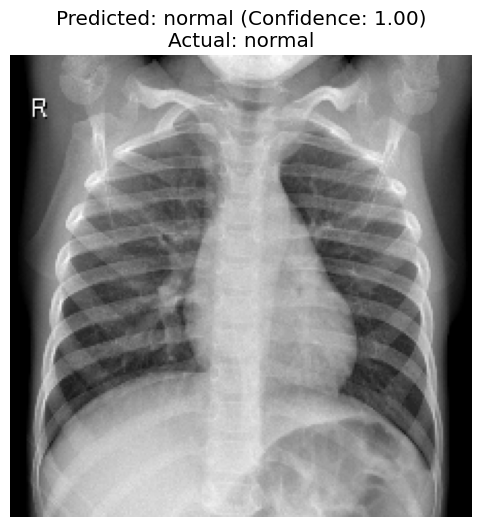

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


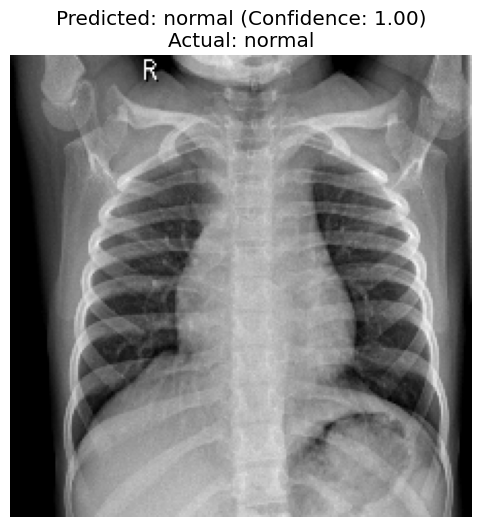

In [29]:
# Select a few images for visualization (e.g., 2 infected, 2 normal)
num_images_to_display = 4

# Get image paths for infected and normal cases
infected_image_paths = [p for p in imagePaths if 'infected' in p]
normal_image_paths = [p for p in imagePaths if 'normal' in p]

# Randomly select a few images from each class
selected_infected_paths = np.random.choice(infected_image_paths, num_images_to_display // 2, replace=False)
selected_normal_paths = np.random.choice(normal_image_paths, num_images_to_display // 2, replace=False)

# Combine and shuffle the selected paths
selected_image_paths = np.concatenate((selected_infected_paths, selected_normal_paths))
np.random.shuffle(selected_image_paths)

print(f"Displaying predictions for {len(selected_image_paths)} images:")

# Loop through selected image paths and display predictions
for img_path in selected_image_paths:
    image = cv2.imread(img_path)
    if image is None:
        print(f"Warning: Could not load image at {img_path}. Skipping.")
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    resized_image = cv2.resize(image, (224, 224))
    img_for_prediction = np.reshape(resized_image, (1, 224, 224, 3)) / 255.0 # Scale for model input

    # Make prediction
    prediction = model.predict(img_for_prediction)
    predicted_class_idx = np.argmax(prediction)
    predicted_label = lb.classes_[predicted_class_idx]

    # Display image and prediction
    plt.figure(figsize=(6, 6))
    plt.imshow(resized_image)
    plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})\nActual: {img_path.split(os.path.sep)[-2]}")
    plt.axis('off')
    plt.show()

In [30]:
img.shape

(1, 224, 224, 3)

END OF VGG16


WITHOUT PRETRAINED MODEL

In [31]:
model = Sequential()
model.add(Conv2D(80, (3, 3),activation='relu', input_shape=(224, 224, 3)))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(32, (3, 3),activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.5))
model.add(Conv2D(32, (3, 3),activation='relu'))


model.add(Conv2D(64, (3, 3),activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(2,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)

In [33]:
# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.6154 - loss: 0.7490

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 24s 244ms/step - accuracy: 0.6888 - loss: 0.6331 - val_accuracy: 0.8841 - val_loss: 0.4980
Epoch 2/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8750 - loss: 0.3803

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8750 - loss: 0.3803 - val_accuracy: 0.8986 - val_loss: 0.4821
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.8748 - loss: 0.3644 - val_accuracy: 0.9275 - val_loss: 0.5134
Epoch 4/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7500 - loss: 0.4205 - val_accuracy: 0.9420 - val_loss: 0.3839
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.8866 - loss: 0.3632

68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - accuracy: 0.8895 - loss: 0.3455 - val_accuracy: 0.9710 - val_loss: 0.1629
Epoch 6/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 1.0000 - loss: 0.0052

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0052 - val_accuracy: 0.9710 - val_loss: 0.1871
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - accuracy: 0.9208 - loss: 0.2393 - val_accuracy: 0.9493 - val_loss: 0.1481
Epoch 8/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0209 - val_accuracy: 0.9493 - val_loss: 0.1686
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.9098 - loss: 0.2444 - val_accuracy: 0.9420 - val_loss: 0.1811
Epoch 10/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.1803 - val_accuracy: 0.9420 - val_loss: 0.1798
Epoch 11/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - accuracy: 0.9300 - loss: 0.1995 - val_accuracy: 0.9638 - val_loss: 0.1148
Epoch 12/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8750 - loss: 0.1091 - val_accuracy: 0.9638 - val_loss: 0.1209
Epoch 13/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.9190 - loss: 0.1777 - val_accuracy: 0.9565 - val_los

In [34]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step
              precision    recall  f1-score   support

    infected       0.97      0.97      0.97        64
      normal       0.97      0.97      0.97        74

    accuracy                           0.97       138
   macro avg       0.97      0.97      0.97       138
weighted avg       0.97      0.97      0.97       138



In [35]:
# compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))

[[62  2]
 [ 2 72]]
acc: 0.9710
sensitivity: 0.9688
specificity: 0.9730


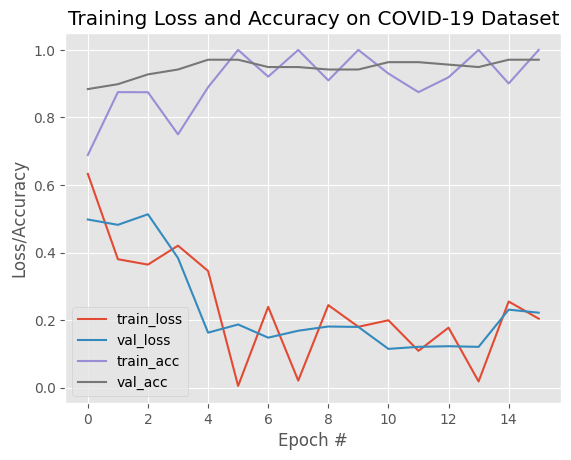

In [36]:
# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


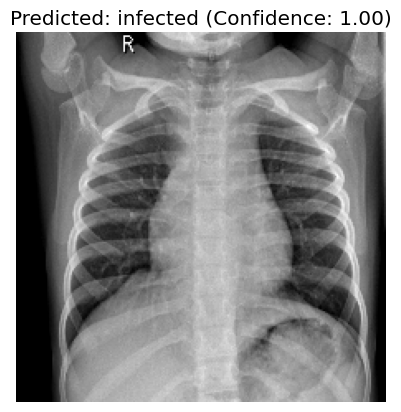

In [37]:
#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
img=np.reshape(image,(1,224,224,3))
model.predict(img)

# Make prediction
prediction = model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

END OF WITHOUT PRETRAINED MODEL

USING INCEPTION-V3 MODEL

In [38]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16,InceptionV3
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split

In [39]:
baseModel = InceptionV3(weights="imagenet", include_top=False, input_tensor=Input(shape=(224, 224, 3)))
#construct the head of the model that will be placed on top of the
#the base model

headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)


model= Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [40]:
model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)

In [41]:
# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.7604 - loss: 0.5533

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 52s 504ms/step - accuracy: 0.8545 - loss: 0.3783 - val_accuracy: 0.9420 - val_loss: 0.1019
Epoch 2/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 1.0000 - loss: 0.0673

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 0.0673 - val_accuracy: 0.9420 - val_loss: 0.1019
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - accuracy: 0.9282 - loss: 0.1756 - val_accuracy: 0.9203 - val_loss: 0.2017
Epoch 4/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7500 - loss: 0.4960 - val_accuracy: 0.9203 - val_loss: 0.1998
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step - accuracy: 0.9282 - loss: 0.2253 - val_accuracy: 0.9855 - val_loss: 0.0893
Epoch 6/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.1256 - val_accuracy: 0.9855 - val_loss: 0.0872
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.9429 - loss: 0.1680 - val_accuracy: 0.9710 - val_loss: 0.0622
Epoch 8/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8750 - loss: 0.1130 - val_accuracy: 0.9710 - val_loss: 0.0630
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - accuracy: 0.9448 - loss: 0.1442 - val_accuracy: 0.9710 - val_loss: 0

In [42]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 548ms/step
              precision    recall  f1-score   support

    infected       0.98      0.98      0.98        64
      normal       0.99      0.99      0.99        74

    accuracy                           0.99       138
   macro avg       0.99      0.99      0.99       138
weighted avg       0.99      0.99      0.99       138



In [43]:
# compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))

[[63  1]
 [ 1 73]]
acc: 0.9855
sensitivity: 0.9844
specificity: 0.9865


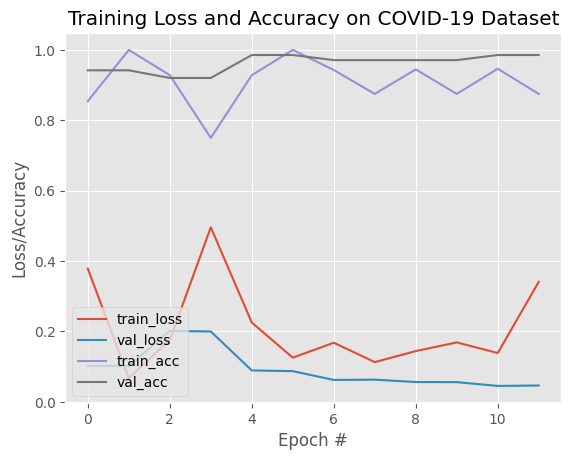

In [44]:
# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


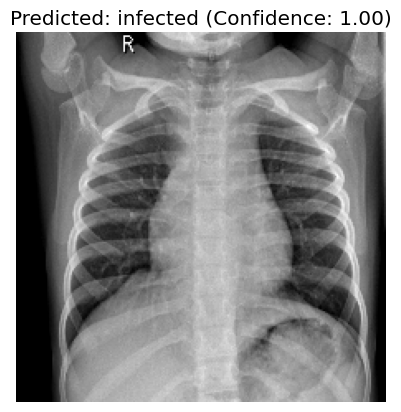

In [45]:


#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
img=np.reshape(image,(1,224,224,3))
model.predict(img)

# Make prediction
prediction = model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

END OF INCEPTION V3 MODEL

RESNET50

In [46]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

In [47]:
res = ResNet50(weights="imagenet", include_top=False, input_tensor=Input(shape=(224, 224, 3)))
outputs = res.output
outputs = Flatten(name="flatten")(outputs)
outputs = Dropout(0.5)(outputs)
outputs = Dense(2, activation="softmax")(outputs)
model = Model(inputs=res.input, outputs=outputs)
for layer in res.layers:
  layer.trainable = False


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [48]:
model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)

In [49]:
# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.6176 - loss: 1.4645

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 35s 336ms/step - accuracy: 0.6777 - loss: 0.9664 - val_accuracy: 0.7899 - val_loss: 0.4369
Epoch 2/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6250 - loss: 1.0259 - val_accuracy: 0.8551 - val_loss: 0.3660
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.7699 - loss: 0.5858

68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - accuracy: 0.7919 - loss: 0.5314 - val_accuracy: 0.9493 - val_loss: 0.1697
Epoch 4/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8750 - loss: 0.2543

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8750 - loss: 0.2543 - val_accuracy: 0.9348 - val_loss: 0.2046
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 128ms/step - accuracy: 0.8250 - loss: 0.4294 - val_accuracy: 0.8913 - val_loss: 0.2788
Epoch 6/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8750 - loss: 0.2884 - val_accuracy: 0.9420 - val_loss: 0.1812
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.8324 - loss: 0.4427 - val_accuracy: 0.9638 - val_loss: 0.1113
Epoch 8/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7500 - loss: 0.6518 - val_accuracy: 0.9638 - val_loss: 0.0992
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - accuracy: 0.8066 - loss: 0.5820 - val_accuracy: 0.7101 - val_loss: 0.6810
Epoch 10/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8750 - loss: 0.6101 - val_accuracy: 0.8333 - val_loss: 0.4283
Epoch 11/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.8269 - loss: 0.5722 - val_accuracy: 0.9710 - val_los

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 0.1818 - val_accuracy: 0.9710 - val_loss: 0.0760
Epoch 13/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.8932 - loss: 0.2965 - val_accuracy: 0.9493 - val_loss: 0.1579
Epoch 14/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8750 - loss: 0.2072 - val_accuracy: 0.9710 - val_loss: 0.1342
Epoch 15/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.8895 - loss: 0.3292 - val_accuracy: 0.9638 - val_loss: 0.1375
Epoch 16/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7500 - loss: 0.4106 - val_accuracy: 0.9710 - val_loss: 0.0897
Epoch 17/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - accuracy: 0.8748 - loss: 0.3364 - val_accuracy: 0.9710 - val_loss: 0.0830
Epoch 18/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.1831 - val_accuracy: 0.9638 - val_loss: 0.1382
Epoch 19/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.8656 - loss: 0.4584 - val_accuracy: 0.9710 - va

In [50]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 353ms/step
              precision    recall  f1-score   support

    infected       0.97      0.97      0.97        64
      normal       0.97      0.97      0.97        74

    accuracy                           0.97       138
   macro avg       0.97      0.97      0.97       138
weighted avg       0.97      0.97      0.97       138



In [51]:
# compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))

[[62  2]
 [ 2 72]]
acc: 0.9710
sensitivity: 0.9688
specificity: 0.9730


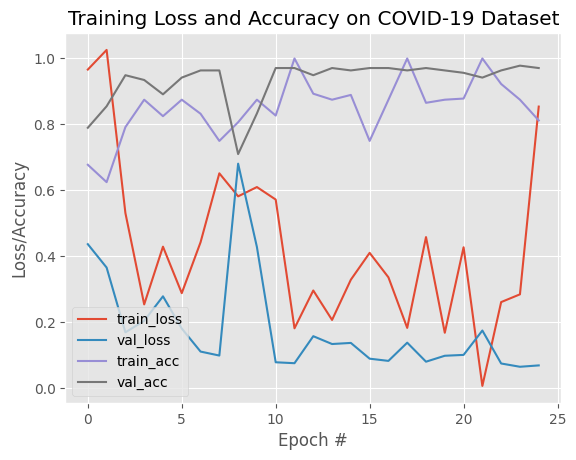

In [52]:
# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


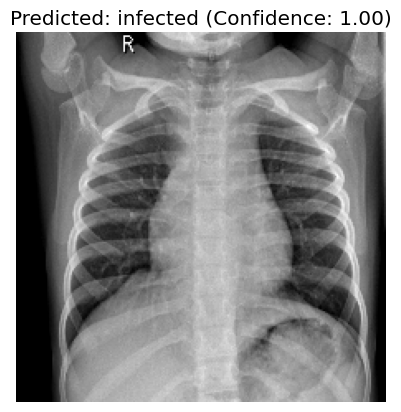

In [53]:


#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
img=np.reshape(image,(1,224,224,3))
model.predict(img)

# Make prediction
prediction = model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

END OF RESNET50


MOBILENET BY GOOGLE


In [54]:
import tensorflow as tf

In [55]:
IMG_SHAPE = (224,224,3)

# Create the base model from the pre-trained model MobileNet V2
baseModel = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)


model= Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [56]:
model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)

In [57]:
# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.6643 - loss: 0.7957

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 76s 792ms/step - accuracy: 0.7864 - loss: 0.5246 - val_accuracy: 0.9855 - val_loss: 0.0831
Epoch 2/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8750 - loss: 0.3934

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8750 - loss: 0.3934 - val_accuracy: 0.9855 - val_loss: 0.0834
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9258 - loss: 0.2045

68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 125ms/step - accuracy: 0.9208 - loss: 0.2102 - val_accuracy: 0.9928 - val_loss: 0.0545
Epoch 4/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7500 - loss: 1.3906 - val_accuracy: 0.9928 - val_loss: 0.0545
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9160 - loss: 0.2051

68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - accuracy: 0.9337 - loss: 0.1866 - val_accuracy: 0.9928 - val_loss: 0.0419
Epoch 6/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 0.0871

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 0.0871 - val_accuracy: 0.9928 - val_loss: 0.0415
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 111ms/step - accuracy: 0.9355 - loss: 0.1832 - val_accuracy: 0.9928 - val_loss: 0.0553
Epoch 8/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0875 - val_accuracy: 0.9855 - val_loss: 0.0531
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.9355 - loss: 0.1540 - val_accuracy: 0.9855 - val_loss: 0.0461
Epoch 10/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8750 - loss: 0.1339 - val_accuracy: 0.9783 - val_loss: 0.0472
Epoch 11/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.9392 - loss: 0.1447 - val_accuracy: 0.9855 - val_loss: 0.0478
Epoch 12/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0712 - val_accuracy: 0.9855 - val_loss: 0.0489
Epoch 13/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.9540 - loss: 0.1223 - val_accuracy: 0.9855 - val_loss:

In [58]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 745ms/step
              precision    recall  f1-score   support

    infected       0.97      1.00      0.98        64
      normal       1.00      0.97      0.99        74

    accuracy                           0.99       138
   macro avg       0.98      0.99      0.99       138
weighted avg       0.99      0.99      0.99       138



In [59]:
# compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))

[[64  0]
 [ 2 72]]
acc: 0.9855
sensitivity: 1.0000
specificity: 0.9730


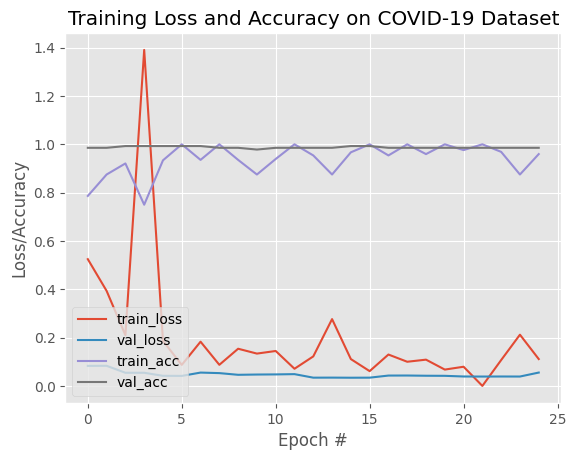

In [60]:
# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


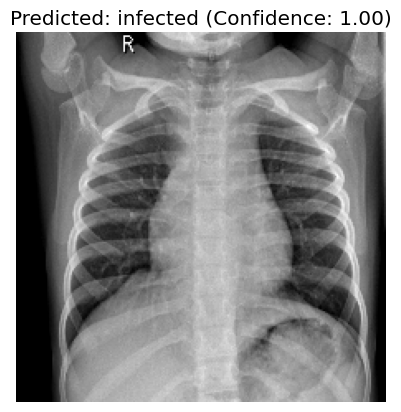

In [61]:


#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
img=np.reshape(image,(1,224,224,3))
model.predict(img)

# Make prediction
prediction = model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

END OF MOBILENET


NASNetlarge

In [62]:
from tensorflow.keras.applications.nasnet import NASNetLarge


In [63]:
IMG_SHAPE = (224,224,3)

# Create the base model from the pre-trained model MobileNet V2
baseModel = tf.keras.applications.NASNetLarge(include_top=False,weights='imagenet',input_tensor=Input(shape=(224, 224, 3)))
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)


model= Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False


343610240/343610240 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step


In [64]:
# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.8877 - loss: 0.3050 - val_accuracy: 0.9638 - val_loss: 0.1490
Epoch 2/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - accuracy: 1.0000 - loss: 0.0208

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 1.0000 - loss: 0.0208 - val_accuracy: 0.9638 - val_loss: 0.1470
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - accuracy: 0.9466 - loss: 0.1321 - val_accuracy: 0.9710 - val_loss: 0.1536
Epoch 4/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 1.0000 - loss: 0.0349 - val_accuracy: 0.9710 - val_loss: 0.1623
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 168ms/step - accuracy: 0.9521 - loss: 0.1565 - val_accuracy: 0.9638 - val_loss: 0.1289
Epoch 6/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 1.0000 - loss: 0.1032 - val_accuracy: 0.9638 - val_loss: 0.1272
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 171ms/step - accuracy: 0.9558 - loss: 0.1140 - val_accuracy: 0.9710 - val_loss: 0.1348
Epoch 8/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 1.0000 - loss: 6.7185e-04 - val_accuracy: 0.9710 - val_loss: 0.1370
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 163ms/step - accuracy: 0.9669 - loss: 0.1020 - val_accuracy: 0.9783 - 

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step
              precision    recall  f1-score   support

    infected       1.00      0.95      0.98        64
      normal       0.96      1.00      0.98        74

    accuracy                           0.98       138
   macro avg       0.98      0.98      0.98       138
weighted avg       0.98      0.98      0.98       138

[[61  3]
 [ 0 74]]
acc: 0.9783
sensitivity: 0.9531
specificity: 1.0000


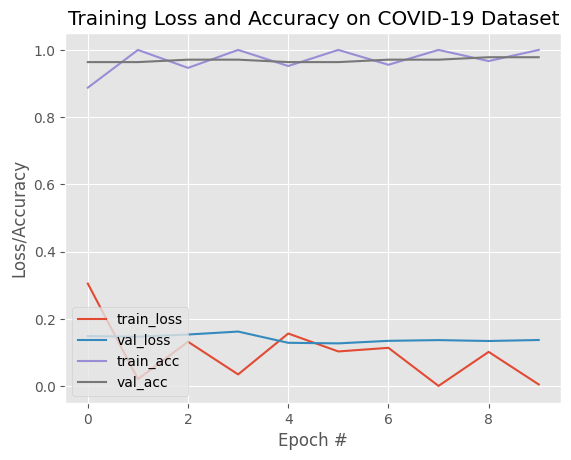

In [65]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))



  # compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))


# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 35s 35s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


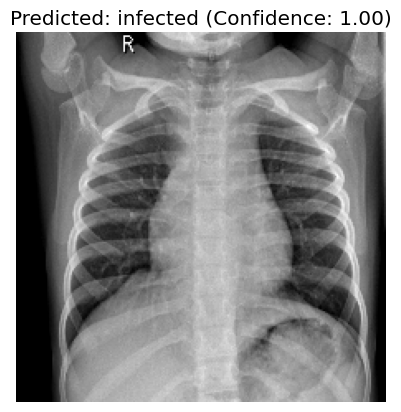

In [66]:

#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
img=np.reshape(image,(1,224,224,3))
model.predict(img)

# Make prediction
prediction = model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

END OF NASNetLarge


Xception MODEL

### Re-initializing Data Augmentation and Splits

This cell re-defines the `trainAug` object and re-creates the training and testing data splits (`trainX`, `trainY`, `testX`, `testY`) and `LabelBinarizer` (`lb`). This is necessary to ensure these variables are available and correctly configured for the models that follow, especially after potential kernel restarts or out-of-order execution that might clear their definitions.

In [4]:
import os
import numpy as np
import cv2 # Assuming cv2 is needed for image processing based on earlier cells
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Re-define DIR_NAME and collect image paths
DIR_NAME = '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/'
imagePaths=[]
# Define common image extensions
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff', '.webp')

for dirname, _, filenames in os.walk(DIR_NAME):
    for filename in filenames:
        if filename.lower().endswith(IMAGE_EXTENSIONS): # Filter for image files
            imagePaths.append(os.path.join(dirname, filename))

# Load and preprocess images, create data and labels arrays
data = []
labels = []
# loop over the image paths
for imagePath in imagePaths:
    # extract the class label from the filename
    label = imagePath.split(os.path.sep)[-2]
    # load the image, swap color channels, and resize it to be a fixed
    # 224x224 pixels while ignoring aspect ratio
    image = cv2.imread(imagePath)
    if image is None: # Added error handling for images that might fail to load
        print(f"Warning: Could not load image at {imagePath}. Skipping.")
        continue
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))
    # update the data and labels lists, respectively
    data.append(image)
    labels.append(label)
# convert the data and labels to NumPy arrays while scaling the pixel
# intensities to the range [0, 1]
data = np.array(data) / 255.0
labels = np.array(labels)

# perform one-hot encoding on the labels
lb = LabelBinarizer()
labels = lb.fit_transform(labels)
labels = to_categorical(labels)
# partition the data into training and testing splits using 80% of
# the data for training and the remaining 20% for testing
(trainX, testX, trainY, testY) = train_test_split(data, labels,
    test_size=0.20, stratify=labels, random_state=42)
# initialize the training data augmentation object
trainAug = ImageDataGenerator(shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,	rotation_range=15,
    fill_mode="nearest")

In [2]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.preprocessing import image
#from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

In [5]:
import tensorflow as tf

IMG_SHAPE = (224,224,3)

# Create the base model from the pre-trained model Xception
baseModel = tf.keras.applications.Xception(include_top=False,weights='imagenet',input_tensor=tf.keras.layers.Input(shape=(224, 224, 3)))
headModel = baseModel.output
headModel = tf.keras.layers.AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = tf.keras.layers.Dropout(0.5)(headModel)
headModel = tf.keras.layers.Flatten(name="flatten")(headModel)
headModel = tf.keras.layers.Dense(64, activation="relu")(headModel)
headModel = tf.keras.layers.Dropout(0.5)(headModel)
headModel = tf.keras.layers.Dense(2, activation="softmax")(headModel)


Xception_model= tf.keras.models.Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [3]:
import os
import numpy as np
import cv2 # Assuming cv2 is needed for image processing based on earlier cells
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Re-define DIR_NAME and collect image paths
DIR_NAME = '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/'
imagePaths=[]
# Define common image extensions
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff', '.webp')

for dirname, _, filenames in os.walk(DIR_NAME):
    for filename in filenames:
        if filename.lower().endswith(IMAGE_EXTENSIONS): # Filter for image files
            imagePaths.append(os.path.join(dirname, filename))

# Load and preprocess images, create data and labels arrays
data = []
labels = []
# loop over the image paths
for imagePath in imagePaths:
	# extract the class label from the filename
	label = imagePath.split(os.path.sep)[-2]
	# load the image, swap color channels, and resize it to be a fixed
	# 224x224 pixels while ignoring aspect ratio
	image = cv2.imread(imagePath)
	if image is None: # Added error handling for images that might fail to load
		print(f"Warning: Could not load image at {imagePath}. Skipping.")
		continue
	image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
	image = cv2.resize(image, (224, 224))
	# update the data and labels lists, respectively
	data.append(image)
	labels.append(label)
# convert the data and labels to NumPy arrays while scaling the pixel
# intensities to the range [0, 1]
data = np.array(data) / 255.0
labels = np.array(labels)

# perform one-hot encoding on the labels
lb = LabelBinarizer()
labels = lb.fit_transform(labels)
labels = to_categorical(labels)
# partition the data into training and testing splits using 80% of
# the data for training and the remaining 20% for testing
(trainX, testX, trainY, testY) = train_test_split(data, labels,
	test_size=0.20, stratify=labels, random_state=42)
# initialize the training data augmentation object
trainAug = ImageDataGenerator(shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,	rotation_range=15,
	fill_mode="nearest")

import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.layers import AveragePooling2D, Dropout, Flatten, Dense, Input
from tensorflow.keras.models import Model

IMG_SHAPE = (224,224,3)

# Create the base model from the pre-trained model Xception
baseModel = Xception(include_top=False,weights='imagenet',input_tensor=Input(shape=(224, 224, 3)))
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)


Xception_model = Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False

model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)

# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
Xception_model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = Xception_model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.7994 - loss: 0.4029

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 65s 698ms/step - accuracy: 0.9006 - loss: 0.2552 - val_accuracy: 0.9710 - val_loss: 0.0851
Epoch 2/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 1.0000 - loss: 0.1374

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 0.1374 - val_accuracy: 0.9710 - val_loss: 0.0843
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - accuracy: 0.9576 - loss: 0.1303 - val_accuracy: 0.9855 - val_loss: 0.0604
Epoch 4/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0054 - val_accuracy: 0.9855 - val_loss: 0.0596
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.9595 - loss: 0.1224 - val_accuracy: 0.9855 - val_loss: 0.0316
Epoch 6/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 0.0641 - val_accuracy: 0.9855 - val_loss: 0.0312
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 131ms/step - accuracy: 0.9742 - loss: 0.0766 - val_accuracy: 0.9783 - val_loss: 0.0465
Epoch 8/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8750 - loss: 0.2748 - val_accuracy: 0.9783 - val_loss: 0.0450
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 175ms/step - accuracy: 0.9742 - loss: 0.0905 - val_accuracy: 0.9928 - val_loss

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
              precision    recall  f1-score   support

    infected       1.00      0.97      0.98        64
      normal       0.97      1.00      0.99        74

    accuracy                           0.99       138
   macro avg       0.99      0.98      0.99       138
weighted avg       0.99      0.99      0.99       138

[[62  2]
 [ 0 74]]
acc: 0.9855
sensitivity: 0.9688
specificity: 1.0000


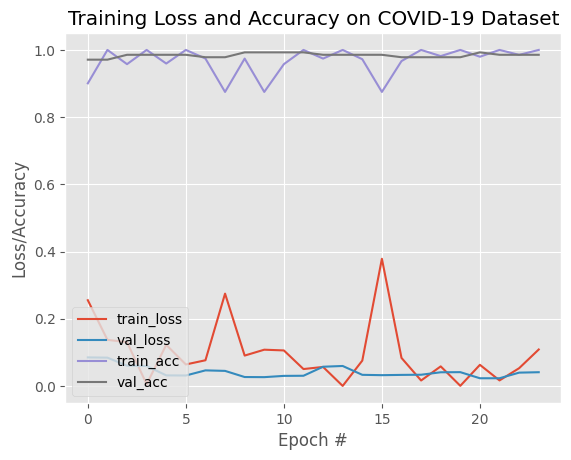

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = Xception_model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))



  # compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))


# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


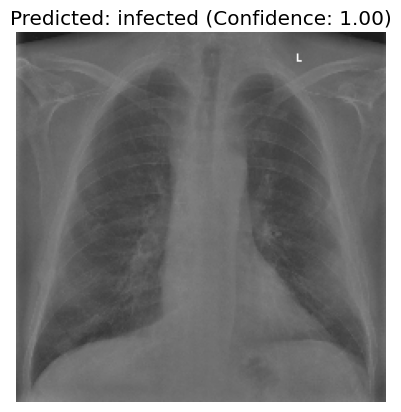

In [8]:
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
resized_image = cv2.resize(image, (224, 224))
img=np.reshape(resized_image,(1,224,224,3))

# Make prediction
prediction = Xception_model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

END OF XCEPTION

DENSENET121

In [9]:
from tensorflow.keras.applications import DenseNet121


In [10]:
IMG_SHAPE = (224,224,3)

# Create the base model from the pre-trained model MobileNet V2
baseModel = tf.keras.applications.DenseNet121(include_top=False,weights='imagenet',input_tensor=Input(shape=(224, 224, 3)))
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)


DenseNet121_model= Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [11]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import AveragePooling2D, Dropout, Flatten, Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

IMG_SHAPE = (224,224,3)

# Create the base model from the pre-trained model DenseNet121
baseModel = tf.keras.applications.DenseNet121(include_top=False,weights='imagenet',input_tensor=Input(shape=(224, 224, 3)))
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)


DenseNet121_model= Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False

model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)

# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
DenseNet121_model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = DenseNet121_model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.6373 - loss: 0.8739

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 79s 756ms/step - accuracy: 0.7238 - loss: 0.6477 - val_accuracy: 0.9638 - val_loss: 0.2152
Epoch 2/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.8750 - loss: 0.7536

68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8750 - loss: 0.7536 - val_accuracy: 0.9565 - val_loss: 0.2155
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.8729 - loss: 0.3088 - val_accuracy: 0.9710 - val_loss: 0.1094
Epoch 4/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8750 - loss: 0.2188 - val_accuracy: 0.9638 - val_loss: 0.1122
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.8827 - loss: 0.2679

68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.8950 - loss: 0.2702 - val_accuracy: 0.9783 - val_loss: 0.0993
Epoch 6/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 1.0000 - loss: 0.1737

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 1.0000 - loss: 0.1737 - val_accuracy: 0.9783 - val_loss: 0.0984
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.9190 - loss: 0.2306 - val_accuracy: 0.9710 - val_loss: 0.1043
Epoch 8/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7500 - loss: 0.4178 - val_accuracy: 0.9710 - val_loss: 0.1039
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.9061 - loss: 0.2459 - val_accuracy: 0.9783 - val_loss: 0.0957
Epoch 10/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0776 - val_accuracy: 0.9783 - val_loss: 0.0963
Epoch 11/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.9558 - loss: 0.1485 - val_accuracy: 0.9783 - val_loss: 0.0798
Epoch 12/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0338 - val_accuracy: 0.9783 - val_loss: 0.0791
Epoch 13/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.9282 - loss: 0.1996 - val_accuracy: 0.9783 - val_los

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 29s 938ms/step
              precision    recall  f1-score   support

    infected       0.98      0.97      0.98        64
      normal       0.97      0.99      0.98        74

    accuracy                           0.98       138
   macro avg       0.98      0.98      0.98       138
weighted avg       0.98      0.98      0.98       138

[[62  2]
 [ 1 73]]
acc: 0.9783
sensitivity: 0.9688
specificity: 0.9865


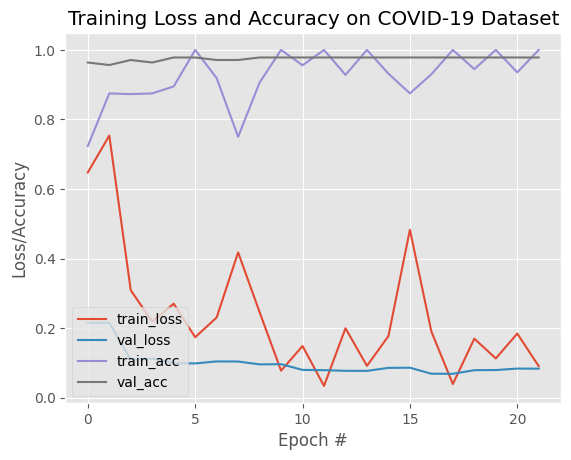

In [12]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = DenseNet121_model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))



  # compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))


# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


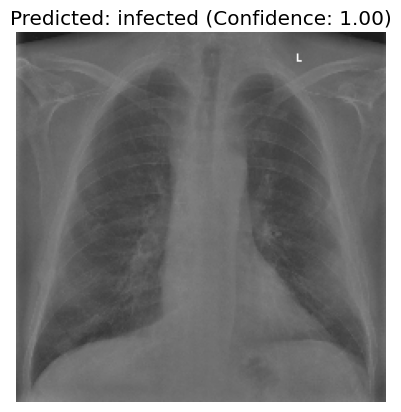

In [13]:
#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
img=np.reshape(image,(1,224,224,3))
DenseNet121_model.predict(img)

# Make prediction
prediction = DenseNet121_model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

END OF DENSE121


INCEPTION RESNETV2

In [14]:
from tensorflow.keras.applications.inception_resnet_v2 import InceptionResNetV2, preprocess_input

In [15]:
IMG_SHAPE = (224,224,3)

# Create the base model from the pre-trained model Xception
baseModel = InceptionResNetV2(include_top=False,weights='imagenet',input_tensor=Input(shape=(224, 224, 3)))
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)


InceptionResNetV2_model= Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False

219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


In [16]:
import tensorflow as tf
from tensorflow.keras.applications.inception_resnet_v2 import InceptionResNetV2
from tensorflow.keras.layers import AveragePooling2D, Dropout, Flatten, Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

IMG_SHAPE = (224,224,3)

# Create the base model from the pre-trained model InceptionResNetV2
baseModel = InceptionResNetV2(include_top=False,weights='imagenet',input_tensor=Input(shape=(224, 224, 3)))
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)


InceptionResNetV2_model= Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False

model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)
# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
InceptionResNetV2_model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = InceptionResNetV2_model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.7520 - loss: 0.5999

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 73s 645ms/step - accuracy: 0.8306 - loss: 0.4053 - val_accuracy: 0.9710 - val_loss: 0.0851
Epoch 2/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6250 - loss: 0.4167 - val_accuracy: 0.9710 - val_loss: 0.0863
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.9199 - loss: 0.2563

68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 150ms/step - accuracy: 0.9079 - loss: 0.2720 - val_accuracy: 0.9275 - val_loss: 0.1623
Epoch 4/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6250 - loss: 0.3944 - val_accuracy: 0.9203 - val_loss: 0.1710
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.9079 - loss: 0.2401 - val_accuracy: 0.9783 - val_loss: 0.0671
Epoch 6/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8750 - loss: 0.1554 - val_accuracy: 0.9783 - val_loss: 0.0660
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9081 - loss: 0.2594

68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 144ms/step - accuracy: 0.9227 - loss: 0.2181 - val_accuracy: 0.9710 - val_loss: 0.0628
Epoch 8/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 1.0000 - loss: 0.0708

68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 1.0000 - loss: 0.0708 - val_accuracy: 0.9710 - val_loss: 0.0571
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 128ms/step - accuracy: 0.9337 - loss: 0.1496 - val_accuracy: 0.9638 - val_loss: 0.0835
Epoch 10/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 0.0318 - val_accuracy: 0.9638 - val_loss: 0.0836
Epoch 11/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.9429 - loss: 0.1602 - val_accuracy: 0.9855 - val_loss: 0.0332
Epoch 12/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8750 - loss: 0.1765 - val_accuracy: 0.9855 - val_loss: 0.0320
Epoch 13/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - accuracy: 0.9466 - loss: 0.1198 - val_accuracy: 0.9855 - val_loss: 0.0343
Epoch 14/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 0.0209 - val_accuracy: 0.9783 - val_loss: 0.0344
Epoch 15/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.9503 - loss: 0.1448 - val_accuracy: 0.9710 - va

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 28s 927ms/step
              precision    recall  f1-score   support

    infected       1.00      0.97      0.98        64
      normal       0.97      1.00      0.99        74

    accuracy                           0.99       138
   macro avg       0.99      0.98      0.99       138
weighted avg       0.99      0.99      0.99       138

[[62  2]
 [ 0 74]]
acc: 0.9855
sensitivity: 0.9688
specificity: 1.0000


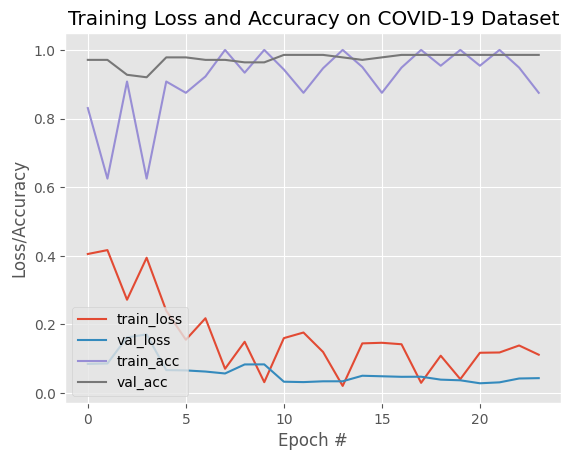

In [17]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = InceptionResNetV2_model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))



  # compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))


# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


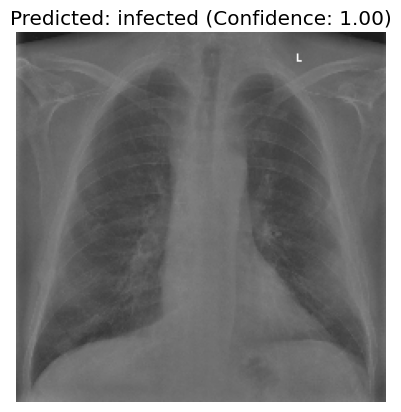

In [18]:
#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
img=np.reshape(image,(1,224,224,3))
InceptionResNetV2_model.predict(img)

# Make prediction
prediction = InceptionResNetV2_model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

END OF INCEPTION RESNETV2